# Introduction to DL

## Perceptron

In [82]:
import numpy as np
from sklearn.linear_model import Perceptron
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
list(iris)

X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target == 0) # Setosa

per_clf = Perceptron()
per_clf.fit(X, y)

X_new = [[1.5, 0.5], [1.4, 1.9]]
print(per_clf.predict(X_new))

[ True False]


## Regression MLP

In [83]:
from sklearn.datasets import fetch_california_housing
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

housing = fetch_california_housing(as_frame=True)
X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full)

mlp_reg = MLPRegressor(hidden_layer_sizes=[50, 50, 50], max_iter=500)
pipeline = make_pipeline(StandardScaler(), mlp_reg)
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_valid)

print(f"RMSE: {root_mean_squared_error(y_valid, y_pred)}")

RMSE: 0.5422933922066825


## Classification MLP

In [84]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

iris = load_iris(as_frame=True)
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5)

mlp_clf = MLPClassifier(hidden_layer_sizes=[10], max_iter=500)
mlp_clf.fit(X_train, y_train)

y_pred = mlp_clf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

Accuracy: 0.9066666666666666


c:\Users\Yehor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


# MLPs via Keras

In [85]:
import keras
import tensorflow as tf
import numpy as np

fashion_mnist = keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test_full, y_test_full) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000] # cutting of 5000 indexes from end
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:] # taking cutted of 5000 indexes from end

print(X_train.shape)
print(X_train.dtype)

X_train, X_valid, X_test = X_train / 255., X_valid / 255., X_test / 255.

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

print(f"Labels: {[(i, label) for i, label in zip(range(len(class_names)), class_names)]}")

(55000, 28, 28)
uint8
Labels: [(0, 'T-shirt/top'), (1, 'Trouser'), (2, 'Pullover'), (3, 'Dress'), (4, 'Coat'), (5, 'Sandal'), (6, 'Shirt'), (7, 'Sneaker'), (8, 'Bag'), (9, 'Ankle boot')]


In [86]:
keras.backend.clear_session()

model = keras.Sequential()
model.add(keras.layers.Input(shape=(28, 28)))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(300, activation="relu"))
model.add(keras.layers.Dense(100, activation="relu"))

# --- or ---

model = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(), # converts 28x28 matrix to a flattene array-vector of shape 7845
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(10, activation="softmax"),
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [87]:
print(model.get_layer("dense_2") is model.layers[1])

dense_layer_2 = model.get_layer("dense_3")
print(f"Layer parameters (weights): {dense_layer_2.get_weights()[0]}") # get_weights() -> (weights, biases)
print(f"Weights shape: {dense_layer_2.get_weights()[0].shape}")

True
Layer parameters (weights): [[ 0.0849405  -0.05487633 -0.01293104 ...  0.11440273  0.11951113
   0.03875271]
 [-0.02215626 -0.04415446  0.0992396  ...  0.0240322  -0.02991329
   0.02473555]
 [ 0.10484607 -0.10210162 -0.04953209 ...  0.02560366  0.04459666
  -0.11007109]
 ...
 [-0.11057961 -0.00044116 -0.04668459 ...  0.06510574  0.02331557
   0.09742989]
 [-0.09569248 -0.00854725 -0.03167363 ... -0.00235327  0.08365079
  -0.02005069]
 [-0.07711461 -0.05892041 -0.04810936 ...  0.06748737 -0.06493974
  -0.08045713]]
Weights shape: (300, 100)


In [88]:
model.compile(loss="sparse_categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

In [89]:
history = model.fit(X_train, y_train, epochs=30, validation_split=0.2)

Epoch 1/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 1s 967us/step - accuracy: 0.7550 - loss: 0.7664 - val_accuracy: 0.8124 - val_loss: 0.5458
Epoch 2/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 1s 875us/step - accuracy: 0.8265 - loss: 0.5035 - val_accuracy: 0.8293 - val_loss: 0.4883
Epoch 3/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 1s 871us/step - accuracy: 0.8399 - loss: 0.4567 - val_accuracy: 0.8449 - val_loss: 0.4548
Epoch 4/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 1s 914us/step - accuracy: 0.8513 - loss: 0.4290 - val_accuracy: 0.8454 - val_loss: 0.4423
Epoch 5/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8571 - loss: 0.4091 - val_accuracy: 0.8539 - val_loss: 0.4242
Epoch 6/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 1s 944us/step - accuracy: 0.8631 - loss: 0.3928 - val_accuracy: 0.8592 - val_loss: 0.4054
Epoch 7/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 1s 897us/step - accuracy: 0.8682 - loss: 0.3782 - val_accuracy: 0.8627 - val_loss: 0.3984
Epoch 8/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 1s 893us/step - accuracy: 0.8718 - l

['accuracy', 'loss', 'val_accuracy', 'val_loss']


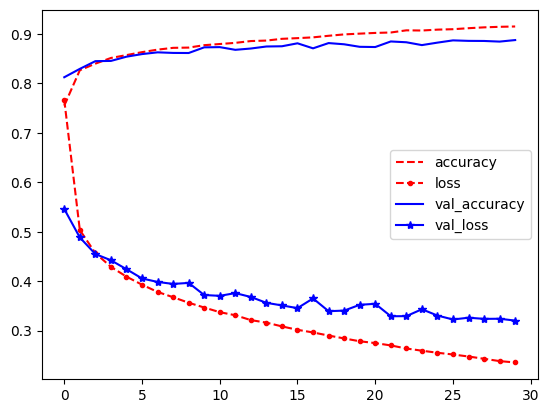

In [90]:
import matplotlib.pyplot as plt
import pandas as pd

print(list(history.history))
pd.DataFrame(history.history).plot(
    style=["r--", "r--.", "b-", "b-*"]
)
plt.show()

In [91]:
model.evaluate(X_valid, y_valid)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 757us/step - accuracy: 0.8840 - loss: 0.3089


[0.30891966819763184, 0.8840000033378601]